In [2]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)
print(keras.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

2.19.0
3.10.0


In [3]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Colab Notebooks/simpleio1.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,0,2
0,1,3
1,2,4
2,3,5
3,4,6
4,5,7


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
0    0
2    0
dtype: int64


In [6]:
#Add two lines to extract column 0 and column 1 in respectively xs and ys variable
xs = df[0]
ys = df[2]

print("Head of the original DataFrame:")
print(df.head())

Head of the original DataFrame:
   0  2
0  1  3
1  2  4
2  3  5
3  4  6
4  5  7


In [7]:
print("\nHead of xs:")
print(xs.head())
print("\nHead of ys:")
print(ys.head())


Head of xs:
0    1
1    2
2    3
3    4
4    5
Name: 0, dtype: int64

Head of ys:
0    3
1    4
2    5
3    6
4    7
Name: 2, dtype: int64


In [8]:
# Add train test split function to create X_train, X_test, Y_train, Y_test date variables for training and testing (testing data should be 30%)
X_train, X_test, Y_train, Y_test = train_test_split(xs, ys, test_size=0.3, random_state=0)


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (69,)
Shape of X_test: (30,)
Shape of Y_train: (69,)
Shape of Y_test: (30,)


# **Learning Rate Sweep**

# **1. Learning Rate = 0.1 with Adam optimizer**

In [9]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3414.7378
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3180.9055
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2642.6831
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2513.7021
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2333.8633
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1969.2571
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1938.4010
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1661.4626
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1480.8361
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1215.5852
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1193.7308
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1092.8743
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 940.6122
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 910.4531 
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13m

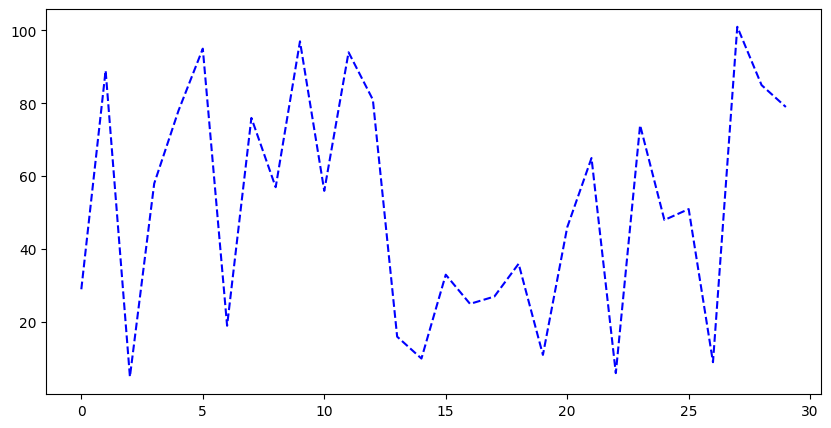

In [10]:
X_new = X_test[:30]
plt.figure(figsize=(10,5))
plt.plot(np.arange(0,len(X_new),1),Y_test[:30],'b--',label='Actual')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


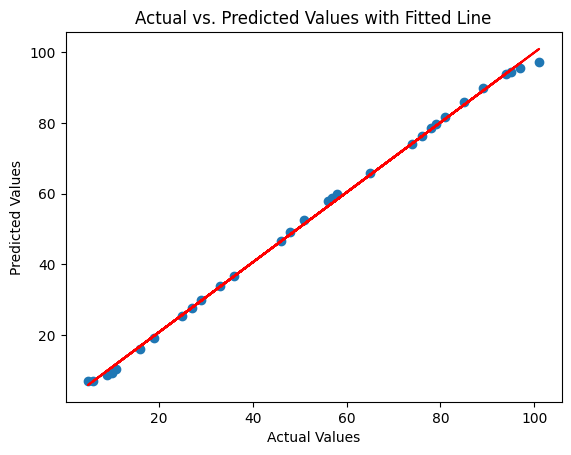

In [11]:
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R^2 Score (Test): 0.9984512329101562
Mean Squared Error (MSE) - Test: 1.4767553806304932
Root Mean Squared Error (RMSE) - Test: 1.2152182440329362
Mean Absolute Error (MAE) - Test: 0.9699600338935852
Mean Squared Error (MSE) - Train: 1.2787115573883057
Root Mean Squared Error (RMSE) - Train: 1.1308012899657949


# **2. Learning Rate = 0.001 with Adam optimizer**

In [13]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3336.6848 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3468.1792
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3518.8647
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3624.3789
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3301.5178
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3538.2200
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3416.5806
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3407.3420
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3433.7751
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3406.3408
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3379.8523
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3525.1123
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3423.5742
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3380.1462
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


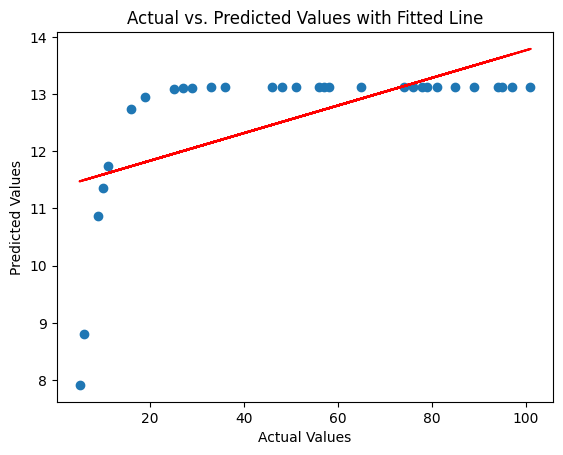

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R^2 Score (Test): -1.5699567794799805
Mean Squared Error (MSE) - Test: 2450.493896484375
Root Mean Squared Error (RMSE) - Test: 49.50246353954897
Mean Absolute Error (MAE) - Test: 39.9073486328125
Mean Squared Error (MSE) - Train: 2270.037353515625
Root Mean Squared Error (RMSE) - Train: 47.644908998922695


In [14]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **3. Learning Rate = 0.01 with Adam optimizer**

In [15]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3411.2200 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3390.0044
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3369.9961 
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3268.9468
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3318.4541
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3416.6177
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3241.7090
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3288.8547
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3264.6328
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3200.9299
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3196.7036
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3045.5361
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3116.5210
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3134.0774
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


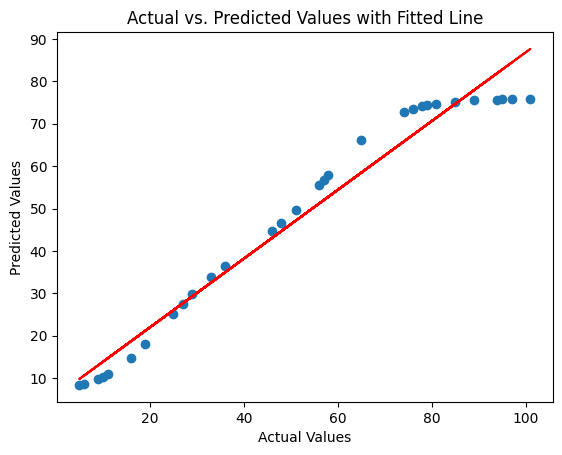

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R^2 Score (Test): 0.9236025810241699
Mean Squared Error (MSE) - Test: 72.84610748291016
Root Mean Squared Error (RMSE) - Test: 8.534993115574855
Mean Absolute Error (MAE) - Test: 4.807995796203613
Mean Squared Error (MSE) - Train: 54.576927185058594
Root Mean Squared Error (RMSE) - Train: 7.387619859268518


In [16]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **4. Learning Rate = 0.5 with Adam optimizer**

In [17]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.5),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3333.6621 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2332.6191
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1735.4695
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1117.0066
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 935.6219 
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 741.6442
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 731.3504
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 640.3877
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1589.6615
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1305.7205
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 980.2499
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 776.5292
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 756.2836
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 788.4615
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


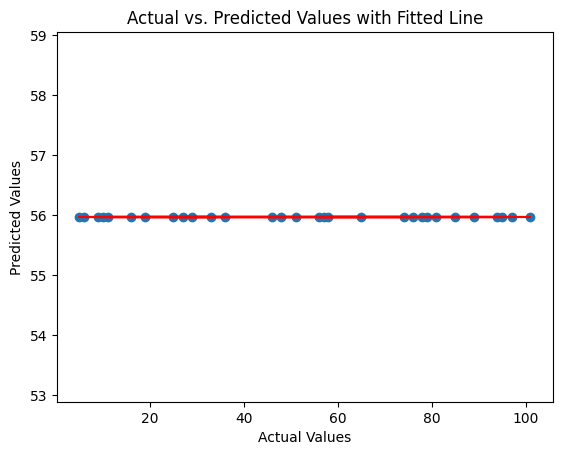

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
R^2 Score (Test): -0.017626404762268066
Mean Squared Error (MSE) - Test: 970.3226318359375
Root Mean Squared Error (RMSE) - Test: 31.1500021161466
Mean Absolute Error (MAE) - Test: 27.133333206176758
Mean Squared Error (MSE) - Train: 772.4312133789062
Root Mean Squared Error (RMSE) - Train: 27.79264675015509


In [18]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **Activation Function Comparison**

# **5. Activation Function: Sigmoid with Adam Optimizer and 0.1 Learning Rate**

In [19]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3374.1348
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3162.4058 
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2863.6448
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2645.8840
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2655.9785
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2565.2654
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2307.7300
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1959.4238
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1908.6698
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1700.9939
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1586.7335
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1455.3884
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1395.5494
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1440.6284
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


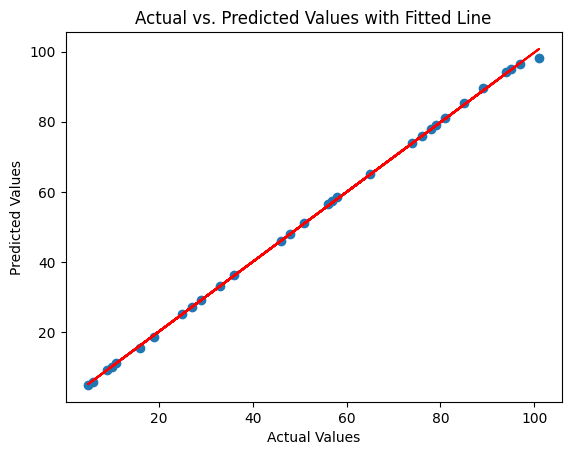

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
R^2 Score (Test): 0.999612033367157
Mean Squared Error (MSE) - Test: 0.36994412541389465
Root Mean Squared Error (RMSE) - Test: 0.6082303226688839
Mean Absolute Error (MAE) - Test: 0.3165655732154846
Mean Squared Error (MSE) - Train: 0.23294603824615479
Root Mean Squared Error (RMSE) - Train: 0.4826448365476987


In [20]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **6. Activation Function: Relu with Adam Optimizer and 0.1 Learning Rate**

In [21]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.relu),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 415.2401
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 48.6342
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 59.9434
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 59.5729
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.8400
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 65.5990
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2352
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 23.7238
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.3461
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.1582 
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.7329
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.8441
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.8016
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.1153
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.2159
Epoch 16/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


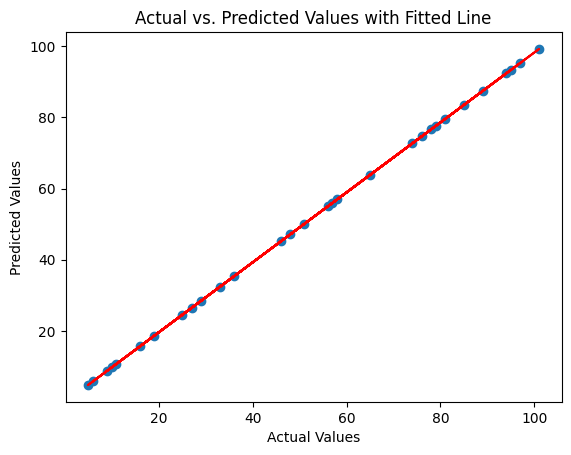

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 Score (Test): 0.9987707138061523
Mean Squared Error (MSE) - Test: 1.1721205711364746
Root Mean Squared Error (RMSE) - Test: 1.0826451732384321
Mean Absolute Error (MAE) - Test: 0.9600244164466858
Mean Squared Error (MSE) - Train: 1.12650465965271
Root Mean Squared Error (RMSE) - Train: 1.0613692381319095


In [22]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **7. Activation Function: Tanh with Adam Optimizer and 0.1 Learning Rate**

In [23]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.tanh),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3233.5322 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2802.6223
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2694.0105
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2286.9243
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2053.4902
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1904.3196
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1592.8248
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1427.8223
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1322.9871
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1223.6689
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1051.4058
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 940.9471
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 831.0239
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 788.2086
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


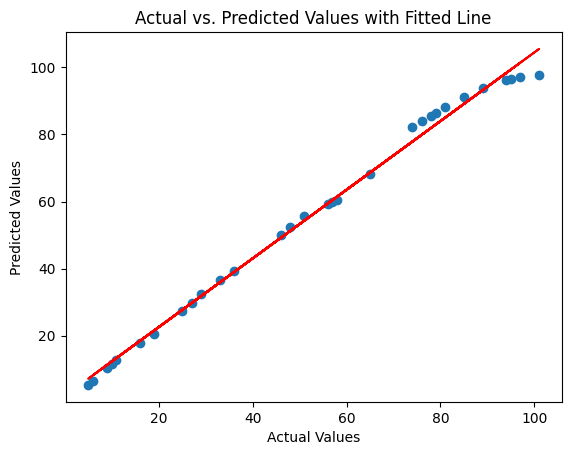

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R^2 Score (Test): 0.9815729260444641
Mean Squared Error (MSE) - Test: 17.57048988342285
Root Mean Squared Error (RMSE) - Test: 4.191716818133455
Mean Absolute Error (MAE) - Test: 3.515275001525879
Mean Squared Error (MSE) - Train: 17.228178024291992
Root Mean Squared Error (RMSE) - Train: 4.150684042937018


In [24]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **Optimizer Comparison**

# **8. Optimizer: SGD with Learning Rate: 0.1 and Activation Funtion: Sigmoid**

In [25]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2453.2944 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 942.8721
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 756.2108
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1027.4137
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 777.0870
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1099.6528
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 822.5795
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1020.0917
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 982.8502 
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 757.0756
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1381.8428
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1392.2230
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 802.4292
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 819.8875
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


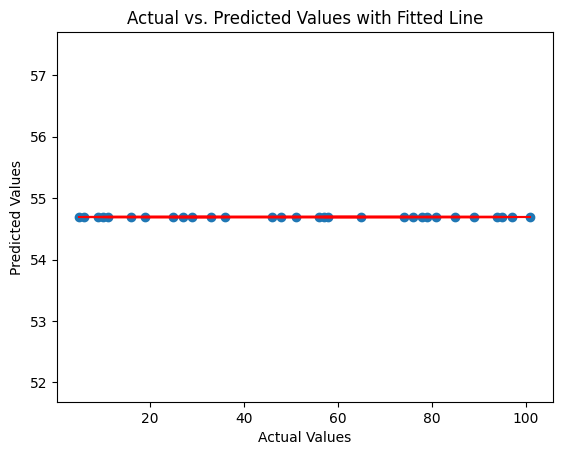

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R^2 Score (Test): -0.008388996124267578
Mean Squared Error (MSE) - Test: 961.5147094726562
Root Mean Squared Error (RMSE) - Test: 31.00830065438376
Mean Absolute Error (MAE) - Test: 27.133333206176758
Mean Squared Error (MSE) - Train: 764.1097412109375
Root Mean Squared Error (RMSE) - Train: 27.64253499972348


In [26]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **9. Optimizer: RMSprop with Learning Rate: 0.1 and Activation Funtion: Sigmoid**

In [27]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3327.0786 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2520.8970
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2072.0422
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2135.8240
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1922.7793
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1672.4736
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1554.8920
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1328.3854
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1161.2058
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1140.1223
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 920.2391
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 869.3760
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 822.6268
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 681.0569
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


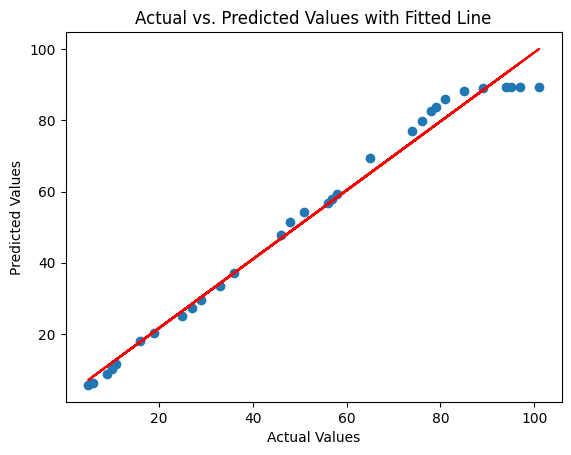

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R^2 Score (Test): 0.9857827425003052
Mean Squared Error (MSE) - Test: 13.556403160095215
Root Mean Squared Error (RMSE) - Test: 3.6819021116937933
Mean Absolute Error (MAE) - Test: 2.575429677963257
Mean Squared Error (MSE) - Train: 10.518277168273926
Root Mean Squared Error (RMSE) - Train: 3.2431893512827656


In [28]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")

# **10. Optimizer: Adagrad with Learning Rate: 0.1 and Activation Funtion: Sigmoid**

In [29]:
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1),
tf.keras.layers.Dense(10,activation=tf.nn.sigmoid),
tf.keras.layers.Dense(1)])

model.summary()

model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1),loss=tf.keras.losses.mse)

# Train the model
model.fit(X_train, Y_train, epochs=500, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3472.6118 
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3365.8887
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2927.6301 
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2782.5571
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2644.4333
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2741.0083
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2683.3857
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2517.1604
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2622.0049
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2649.5227
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2336.2344
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2500.0391
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2406.2075
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2361.5879
Epoch 15/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


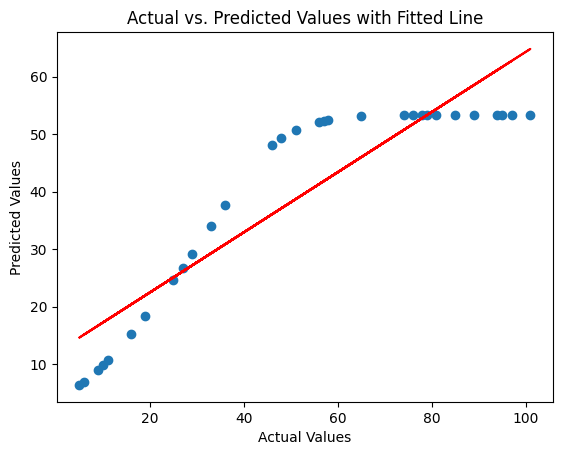

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
R^2 Score (Test): 0.5461047887802124
Mean Squared Error (MSE) - Test: 432.7961730957031
Root Mean Squared Error (RMSE) - Test: 20.80375382222408
Mean Absolute Error (MAE) - Test: 13.29492473602295
Mean Squared Error (MSE) - Train: 352.207763671875
Root Mean Squared Error (RMSE) - Train: 18.767199142969496


In [30]:
X_new = X_test[:30]
y_pred = model.predict(X_new)
plt. plot(Y_test[:30],y_pred, 'o')
m, b = np. polyfit(Y_test[:30],y_pred.flatten(), 1)
plt.plot(Y_test[:30], m * Y_test[:30] + b, 'r-', label='Fitted line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values with Fitted Line')
plt.show()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(Y_test[:30], y_pred)
mse_test = mean_squared_error(Y_test[:30], y_pred)
mae = mean_absolute_error(Y_test[:30], y_pred)
rmse_test = np.sqrt(mse_test)

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)


print(f"R^2 Score (Test): {r2}")
print(f"Mean Squared Error (MSE) - Test: {mse_test}")
print(f"Root Mean Squared Error (RMSE) - Test: {rmse_test}")
print(f"Mean Absolute Error (MAE) - Test: {mae}")
print(f"Mean Squared Error (MSE) - Train: {mse_train}")
print(f"Root Mean Squared Error (RMSE) - Train: {rmse_train}")